# **Question 1: ”Deep Learning for Pricing”**

In [64]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy.stats import norm
import numpy as np

## Black–Scholes Call Price

The goal is to compute the call option price  
$$
C = f(S, K, T, r, \sigma)
$$  
where the pricing function $f(\cdot)$ is known analytically from financial theory.

### Numerical Stability Adjustment

A very small constant $\varepsilon = 10^{-12}$ is introduced to avoid numerical issues such as:
- division by zero,
- taking the logarithm of zero,
- instability when $T$, $S$, or $K$ are very close to zero.

This ensures robust computation when generating large synthetic datasets.

### Definition of $d_1$

The first key quantity in the Black–Scholes model is

$$
d_1 = \frac{\ln\left(\frac{S}{K}\right) + \left(r + \frac{1}{2}\sigma^2\right)T}
{\sigma \sqrt{T}}
$$

**Economic interpretation**:
- $\ln(S/K)$ captures the **moneyness** of the option,
- $rT$ reflects the time value of money under the risk-free rate,
- $\frac{1}{2}\sigma^2T$ adjusts for uncertainty due to volatility,
- the denominator scales total uncertainty over the remaining lifetime of the option.

### Definition of $d_2$

The second key quantity is

$$
d_2 = d_1 - \sigma \sqrt{T}
$$

**Interpretation**:
- $d_2$ measures the standardized log-price at maturity under the risk-neutral measure,
- it is closely related to the probability that the option expires **in the money**.

### Black–Scholes Call Price Formula

The call option price is computed as

$$
C = S \, N(d_1) - K e^{-rT} N(d_2)
$$

where $N(\cdot)$ denotes the cumulative distribution function of the standard normal distribution.

**Interpretation of terms**:
- $S N(d_1)$ represents the expected value of holding the underlying asset,
- $K e^{-rT} N(d_2)$ represents the present value of the expected strike payment,
- the difference gives the fair price of the call option.

### Output Interpretation

The resulting value is the **theoretical, arbitrage-free price** of a European call option.
When computed over many inputs, this function generates a clean and noise-free dataset that
can be used to train and evaluate deep learning models.

In [65]:
def bs_call_price(S, K, T, r, sigma):
    """
    Black–Scholes European Call Option price (no dividends)
    """
    eps = 1e-12

    d1 = (np.log((S + eps) / (K + eps)) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T) + eps)
    d2 = d1 - sigma * np.sqrt(T)

    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

# **1. Data Generation**

### Dataset Size

The number of observations is set to

$$
n = 10{,}000
$$

This provides a sufficiently large dataset to train a deep neural network while
remaining computationally efficient.

### Sampling the Input Features

Each model input is sampled independently from a uniform distribution over a realistic
financial range:

- **Spot price**  
  $$
  S \sim \mathcal{U}(80, 120)
  $$
  Represents different market levels of the underlying asset.

- **Strike price**  
  $$
  K \sim \mathcal{U}(80, 120)
  $$
  Allows for both in-the-money and out-of-the-money options.

- **Time to maturity**  
  $$
  T \sim \mathcal{U}(0.1, 2.0)
  $$
  Covers short- to medium-term maturities.

- **Risk-free rate**  
  $$
  r \sim \mathcal{U}(0.01, 0.05)
  $$
  Reflects plausible annualized interest rates.

- **Volatility**  
  $$
  \sigma \sim \mathcal{U}(0.1, 0.5)
  $$
  Covers low- to high-volatility market environments.

Sampling over wide intervals ensures good coverage of the input space and improves
generalization of the neural network.

### Generating Target Prices

For each sampled parameter tuple $(S, K, T, r, \sigma)$, the **theoretical call option price**
is computed using the Black–Scholes formula:

$$
C = f_{\text{BS}}(S, K, T, r, \sigma)
$$

These prices serve as **noise-free labels** for supervised learning.

### Feature Matrix and Target Vector

The input variables are combined into a feature matrix

$$
X = \begin{bmatrix}
S & K & T & r & \sigma
\end{bmatrix}
$$

with dimension $10{,}000 \times 5$.

The target vector is reshaped into a column vector

$$
y = C
$$

to match the expected input format of machine learning models.

In [52]:
np.random.seed(42)

n = 10_000

S = np.random.uniform(80, 120, n)
K = np.random.uniform(80, 120, n)
T = np.random.uniform(0.1, 2.0, n)
r = np.random.uniform(0.01, 0.05, n)
sigma = np.random.uniform(0.1, 0.5, n)

C = bs_call_price(S, K, T, r, sigma)

X = np.column_stack([S, K, T, r, sigma])
y = C.reshape(-1, 1)

df = pd.DataFrame(X, columns=["S", "K", "T", "r", "sigma"])
df["CallPrice"] = y

df.head()

,S,K,T,r,sigma,CallPrice
0,94.981605,94.945633,1.486997,0.035526,0.219565,12.506503
1,118.028572,93.316484,0.450573,0.028372,0.137927,25.908482
2,109.279758,87.046157,0.758615,0.048580,0.150544,25.485137
3,103.946339,104.290667,1.360233,0.018759,0.172268,9.417948
4,86.240746,99.064966,1.015970,0.033514,0.181461,2.927729


# **2. Model Training**

## Train–Test Split and Feature Scaling

This section prepares the dataset for neural network training by splitting the data
into training and testing sets and applying feature scaling.

### Train–Test Split

The dataset is divided into two mutually exclusive subsets:

- **Training set**: 80% of the data  
- **Test set**: 20% of the data  

Formally,
$$
(X, y) = (X_{\text{train}}, y_{\text{train}}) \cup (X_{\text{test}}, y_{\text{test}})
$$

The test set is held out and **never seen during training**, allowing an unbiased
evaluation of the model’s generalization performance.

A fixed `random_state` is used to ensure **reproducibility** of the split.

### Feature Standardization

Each input feature is standardized using **z-score normalization**:

$$
X^{(j)}_{\text{scaled}} = \frac{X^{(j)} - \mu_j}{\sigma_j}
$$

where:
- $\mu_j$ is the mean of feature $j$ computed on the training set,
- $\sigma_j$ is the corresponding standard deviation.

The scaler is **fit only on the training data** and then applied to both training
and test sets to prevent information leakage.

### Target Scaling

The target variable (call option price) is also standardized:

$$
y_{\text{scaled}} = \frac{y - \mu_y}{\sigma_y}
$$

Scaling the target:
- improves numerical stability,
- leads to smoother loss landscapes,
- accelerates convergence during training.

After prediction, the scaling is inverted to recover prices in original monetary units.

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

x_scaler = StandardScaler()
X_train_sc = x_scaler.fit_transform(X_train)
X_test_sc = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_sc = y_scaler.fit_transform(y_train)
y_test_sc = y_scaler.transform(y_test)

## Neural Network Architecture and Compilation

This section defines, initializes, and compiles the **feedforward neural network**
used to approximate the Black–Scholes pricing function.

### Reproducibility

A fixed random seed is set for TensorFlow to ensure that:
- weight initialization,
- batch ordering,
- training dynamics  

are reproducible across runs.

This is important for consistency when reporting results.

### Model Architecture

The model is a **fully connected feedforward neural network (Multilayer Perceptron, MLP)**.

#### Input Layer
- Input dimension: **5**
- Corresponds to the features $(S, K, T, r, \sigma)$.


#### Hidden Layers

The network contains **four hidden layers**, each with:
- **64 neurons**
- **ReLU activation function**

Mathematically, each hidden layer applies:

$$
h^{(l)} = \max(0, W^{(l)} h^{(l-1)} + b^{(l)})
$$

**Why ReLU?**
- Introduces non-linearity,
- avoids vanishing gradient problems,
- computationally efficient,
- well-suited for deep architectures.

This depth and width provide sufficient expressive power to approximate the highly
nonlinear Black–Scholes pricing function.

In [55]:
tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(5,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

### Model Summary Interpretation

- Each hidden layer outputs a vector of dimension 64.
- Parameter counts increase according to the formula:
  $$
  \text{params} = (\text{input size} + 1) \times \text{output size}
  $$
- All parameters are trainable.
- The total memory footprint is small (≈ 50 KB), making training efficient.

### Role in the Experiment

This architecture is designed to test whether a neural network can **learn the
Black–Scholes pricing formula purely from data**, demonstrating the
**Universal Approximation property** of deep neural networks.

# **3. Evaluation**

In [56]:
history = model.fit(
    X_train_sc,
    y_train_sc,
    validation_split=0.2,
    epochs=300,
    batch_size=256,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=15, restore_best_weights=True
        )
    ],
    verbose=0
)

### Generating Predictions

The neural network produces predictions for the standardized test inputs
$X_{\text{test}}^{\text{sc}}$.  
Because the model was trained on a **scaled target variable**, the predicted values
are transformed back to the original price scale.

This inverse transformation ensures that all evaluation metrics are computed in
**actual monetary units**, making them economically interpretable.

### Coefficient of Determination ($R^2$)

The coefficient of determination is computed as:

$$
R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}
{\sum_{i=1}^n (y_i - \bar{y})^2}
$$

**Interpretation**:
- $R^2 = 0.99978$ indicates that **more than 99.97% of the variance** in theoretical
  Black–Scholes prices is explained by the neural network.
- This extremely high value confirms that the network has successfully learned
  the underlying pricing function.

### Root Mean Squared Error (RMSE)

The RMSE is given by:

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}
$$

**Interpretation**:
- $\text{RMSE} \approx 0.15$ means that, on average, prediction errors are only
  a few cents for option prices that range up to roughly $50$.
- This error level is economically negligible.

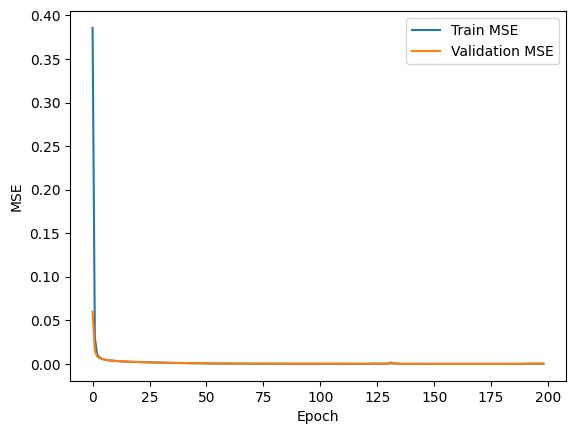

In [57]:
plt.figure()
plt.plot(history.history["loss"], label="Train MSE")
plt.plot(history.history["val_loss"], label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [58]:
y_pred_sc = model.predict(X_test_sc)
y_pred = y_scaler.inverse_transform(y_pred_sc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [59]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² score: {r2:.6f}")
print(f"RMSE: {rmse:.6f}")

R² score: 0.999780
RMSE: 0.152252


### Predicted vs. Theoretical Price Scatter Plot

The scatter plot compares:
- the theoretical Black–Scholes prices (horizontal axis),
- the neural network predictions (vertical axis).

A 45-degree reference line is included to indicate perfect predictions:

$$
\hat{C} = C
$$

### Visual Interpretation of the Plot

- The points lie almost exactly on the 45-degree line.
- There is no visible systematic bias (overpricing or underpricing).
- The spread around the line is minimal, even for high option prices.

This visual evidence strongly supports the numerical performance metrics.

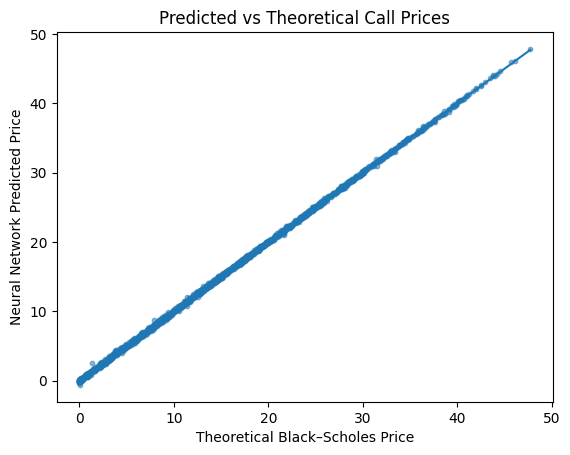

In [60]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5, s=10)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)
plt.xlabel("Theoretical Black–Scholes Price")
plt.ylabel("Neural Network Predicted Price")
plt.title("Predicted vs Theoretical Call Prices")
plt.show()

### Overall Conclusion

The neural network:
- accurately reproduces the Black–Scholes pricing function,
- generalizes extremely well to unseen data,
- demonstrates the **Universal Approximation capability** of deep neural networks
  in a financial pricing context.

The results confirm that complex analytical pricing formulas can be learned directly
from data without explicit knowledge of the closed-form solution.


# **Question 2: Sequence Modeling for Stock Prediction**

# **1. Data Preparation**

In [69]:
import fastbox as fb
#fb.set_server(0) 
#connection via vpn is strongly recommanded

In [70]:
fb.auth()

Please enter your user name and password for authentication.

Please input your user name:

 egrishin.25@saif.sjtu.edu.cn


Please input your password:

 ········


Fastbox: Configuration saved to fastbox_config.pkl.


User authorized.

### Parameter Setup for Data Preparation

- **T = 20**  
  Defines the length of each input sequence.  
  Each training example uses the past 20 daily returns as features to predict the return on the next day (T + 1).

- **INDEX_ID = "000300" (CSI 300)**  
  Specifies a major Chinese market index to serve as the underlying time series.  

- **Date range (last 5 years)**  
  - `to_date` is set to the current date.  
  - `from_date` is set to five years before `to_date`.  

In [119]:
T = 20

INDEX_ID = "000300"   # CSI 300 (major index)

to_date = pd.Timestamp.today().strftime("%Y-%m-%d")
from_date = (pd.Timestamp.today() - pd.DateOffset(years=5)).strftime("%Y-%m-%d")

from_date, to_date

('2021-01-25', '2026-01-25')

In [120]:
# Pull daily index data
df = fb.data.index.daily(
    instrumentid=INDEX_ID,
    complete=True,
    from_date=from_date,
    to_date=to_date
).sort_index()

df.head(), df.columns

(                close       open       high        low          vol  \
 date                                                                  
 2021-01-25  5625.9232  5564.1237  5655.4795  5543.2663  197047019.0   
 2021-01-26  5512.9678  5600.9017  5600.9017  5505.9962  171904590.0   
 2021-01-27  5528.0034  5505.7708  5534.9928  5449.6385  160190841.0   
 2021-01-28  5377.1427  5450.3695  5462.2352  5360.3766  170485585.0   
 2021-01-29  5351.9646  5413.9684  5430.2015  5288.0955  182178784.0   
 
                   amount  
 date                      
 2021-01-25  5.081670e+08  
 2021-01-26  4.150081e+08  
 2021-01-27  3.768926e+08  
 2021-01-28  3.761665e+08  
 2021-01-29  3.902877e+08  ,
 Index(['close', 'open', 'high', 'low', 'vol', 'amount'], dtype='object'))

### Computing Daily Returns

This block constructs the daily return series used as the input time series for all
sequence models.

- If the dataset already provides a **return column** $\texttt{ret}$, it is used directly.
  This avoids unnecessary recomputation and preserves the return definition supplied
  by FastBox.

- If returns are not provided, they are computed from the **closing prices** using
  percentage changes:
  $$
  r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
  $$
  where $P_t$ denotes the closing price at day $t$.

- If neither $\texttt{ret}$ nor $\texttt{close}$ is available, an explicit error is raised
  to prevent silently using incorrect data.

- The resulting return series is:
  - cleaned of missing values,
  - cast to $\texttt{float32}$ for computational efficiency and neural-network compatibility,
  - renamed to $\texttt{ret}$ for consistent downstream processing.

This standardized return series $\{r_t\}$ is used to construct rolling input sequences of
length $T = 20$ and to predict the next-day return $r_{t+1}$.


In [121]:
# Compute daily returns
if "ret" in df.columns:
    ret = df["ret"].dropna()
elif "close" in df.columns:
    ret = df["close"].pct_change().dropna()
else:
    raise ValueError(f"No 'ret' or 'close' column. Columns: {df.columns.tolist()}")

ret = ret.astype("float32").rename("ret")
ret.head()

date
2021-01-26   -0.020078
2021-01-27    0.002727
2021-01-28   -0.027290
2021-01-29   -0.004682
2021-02-01    0.012273
Name: ret, dtype: float32

In [123]:
# Build sequences: X = past T returns, y = next-day return
values = ret.values
X = np.stack([values[i-T:i] for i in range(T, len(values))])  # (N-T, T)
y = values[T:]                                                # (N-T,)
X = X[..., None]                                              # (N-T, T, 1)
dates = ret.index[T:]                                         # aligns with y

# Train/val split (time series, no shuffle)
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_val,   y_val   = X[split:], y[split:]
d_val = dates[split:]

X_train.shape, X_val.shape

((948, 20, 1), (237, 20, 1))

# **2. Model Comparison**

In [124]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

In [125]:
def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

### Model A (LSTM)

This model applies a **Long Short-Term Memory (LSTM)** network to model the sequential
structure of daily stock index returns.

- **Input**:  
  The input tensor has shape $(T, 1)$, where $T = 20$ corresponds to the past 20 daily
  returns, and $1$ denotes a single feature per time step.

- **LSTM layer**:  
  The LSTM layer with 32 hidden units captures temporal dependencies in the return
  sequence. Unlike simple RNNs, LSTMs mitigate the vanishing gradient problem by
  maintaining a memory cell, allowing the model to retain relevant information over
  longer horizons.

- **Dense hidden layer**:  
  A fully connected layer with ReLU activation introduces nonlinearity and maps the
  sequential representation learned by the LSTM to a higher-level feature space.

- **Output layer**:  
  A single linear neuron outputs the predicted next-day return $\hat{r}_{t+1}$.

In [139]:
# Model A — LSTM
def build_lstm(T=20):
    inp = keras.Input(shape=(T, 1))
    x = layers.LSTM(32)(inp)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1)(x)
    return compile_model(keras.Model(inp, out, name="LSTM"))

lstm_model = build_lstm(T)
lstm_model.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

### Model B (Attention)

This model uses a **self-attention mechanism** to explicitly learn which past days
in the 20-day window are most relevant for predicting the next-day return.

- **Projection layer**:  
  The input sequence $x \in \mathbb{R}^{T \times 1}$ is first projected into a higher-
  dimensional embedding space of size $d_{\text{model}} = 32$.  
  This produces a representation $h \in \mathbb{R}^{T \times d_{\text{model}}}$ that
  is suitable for attention operations.

- **Query selection**:  
  The representation of the **most recent day** ($t$) is used as the query
  $q \in \mathbb{R}^{1 \times d_{\text{model}}}$, while all $T$ days act as keys and
  values.  
  This design allows the model to decide which previous days are most informative
  for predicting $r_{t+1}$.

- **Multi-Head Attention**:  
  Multi-head attention computes multiple attention distributions in parallel,
  enabling the model to capture different types of temporal relationships
  (e.g., short-term shocks vs. medium-term trends).  
  The attention weights satisfy
  $$
  \sum_{i=1}^{T} \alpha_i = 1,
  $$
  making them directly interpretable.

- **Attention output**:  
  The attention layer returns a context vector summarizing the relevant information
  from the 20-day window, weighted by learned importance scores.

- **Dense layers**:  
  The context vector is flattened and passed through a ReLU-activated dense layer
  to introduce nonlinearity and refine the representation.

- **Output layer**:  
  A single linear neuron outputs the predicted next-day return $\hat{r}_{t+1}$.

A key advantage of this Attention model is **interpretability**: the learned attention
weights can be visualized to understand which specific days in the past window the
model focuses on, especially during volatile market periods.


In [152]:
# Model B (Attention)
class LastQueryAttention(layers.Layer):
    def __init__(self, d_model=32, num_heads=4, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.proj = layers.Dense(d_model)
        self.mha = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )

    def call(self, x, training=None, return_scores=False):
        h = self.proj(x)       # (B, T, d_model)
        q = h[:, -1:, :]       # (B, 1, d_model) last day as query
        if return_scores:
            out, scores = self.mha(q, h, return_attention_scores=True, training=training)
            return out, scores  # scores: (B, heads, 1, T)
        return self.mha(q, h, training=training)

def build_attention(T=20, d_model=32, num_heads=4):
    inp = keras.Input(shape=(T, 1))
    attn = LastQueryAttention(d_model=d_model, num_heads=num_heads, name="attn")
    x = attn(inp)             # (B, 1, d_model)
    x = layers.Flatten()(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1)(x)
    return compile_model(keras.Model(inp, out, name="Attention"))

attn_model = build_attention(T)
attn_model.summary()

Model: "Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attn (LastQueryAttention)       │ (None, 1, 32)          │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)

### Model C (1D Convolutional Neural Network (1D-CNN))

This model applies **one-dimensional convolutions** to extract local temporal patterns
from the sequence of daily returns.

- **Input**:  
  The input tensor has shape $(T, 1)$, where $T = 20$ corresponds to the past 20 daily
  returns.

- **Conv1D layers**:  
  Two causal convolutional layers with 32 filters and kernel size 3 are used.
  The **causal padding** ensures that the convolution at time $t$ only depends on
  returns from time $t$ and earlier, preventing any look-ahead bias.

  Each convolution acts as a local pattern detector, capturing short-term structures
  such as momentum bursts or brief reversals over neighboring days.

- **Global Max Pooling**:  
  The global max pooling layer aggregates the most salient local features across
  the entire 20-day window, producing a fixed-length representation independent of
  the exact position of the pattern.

- **Dense hidden layer**:  
  A fully connected layer with ReLU activation introduces nonlinearity and combines
  the extracted local features into a higher-level representation.

- **Output layer**:  
  A single linear neuron outputs the predicted next-day return $\hat{r}_{t+1}$.

Compared to recurrent and attention-based models, the 1D-CNN focuses on **local temporal
dependencies** and often converges faster, as it avoids sequential recurrence while
still capturing meaningful short-term patterns in financial time-series data.


In [153]:
# Model C (1D-CNN)
def build_cnn(T=20):
    inp = keras.Input(shape=(T, 1))
    x = layers.Conv1D(32, 3, activation="relu", padding="causal")(inp)
    x = layers.Conv1D(32, 3, activation="relu", padding="causal")(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1)(x)
    return compile_model(keras.Model(inp, out, name="CNN1D"))

cnn_model = build_cnn(T)
cnn_model.summary()

Model: "CNN1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 20, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 20, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,321 (16.88 KB)

 Trainable params: 4,321 (16.88 KB)

 Non-trainable params: 0 (0.00 B)

In [142]:
# Train all three on the SAME dataset/split (X_train, y_train, X_val, y_val)
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
]

EPOCHS = 80
BATCH  = 64

hist_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=callbacks, verbose=0
)

hist_attn = attn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=callbacks, verbose=0
)

hist_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=callbacks, verbose=0
)

# **3. Analysis**

### Validation Loss Curves and Convergence Comparison

The figure shows the **validation Mean Squared Error (MSE)** as a function of training
epochs for the three models: **LSTM**, **Attention**, and **1D-CNN**.

#### Overall behavior

- All three models reach a relatively low validation loss within the first few epochs,
  indicating that the prediction task is learnable from short return histories.
- The validation losses remain stable after the initial epochs, suggesting no severe
  overfitting.

#### Convergence speed

- **1D-CNN**:
  - Achieves the **lowest validation loss** among all models.
  - Reaches near-optimal performance almost immediately and remains stable thereafter.
  - This indicates the **fastest and most stable convergence**.

- **Attention model**:
  - Exhibits larger fluctuations in the first few epochs.
  - Converges faster than the LSTM but is less stable initially due to the additional
    flexibility introduced by learning attention weights.

- **LSTM**:
  - Shows smoother but slower convergence.
  - Settles at a higher validation loss compared to the other two models.

#### Interpretation

The faster convergence of the **1D-CNN** can be attributed to its ability to efficiently
extract **local temporal patterns** through convolutional filters without relying on
recurrent memory or attention reweighting.  
In contrast, the **LSTM** must learn long-term dependencies through sequential recurrence,
which typically slows optimization, while the **Attention model** introduces additional
parameters that increase early training variability.

#### Conclusion

From the validation loss curves, the **1D-CNN converges the fastest and achieves the best
validation performance**, followed by the Attention model, with the LSTM converging the
slowest. This highlights the trade-off between **training efficiency**, **model
complexity**, and **interpretability** in sequence modeling for financial time series.


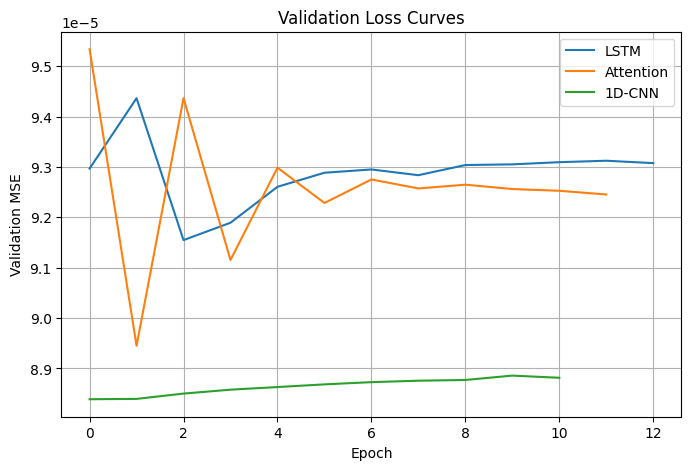

In [143]:
plt.figure(figsize=(8, 5))
plt.plot(hist_lstm.history["val_loss"], label="LSTM")
plt.plot(hist_attn.history["val_loss"], label="Attention")
plt.plot(hist_cnn.history["val_loss"], label="1D-CNN")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

### Quantitative Convergence Criterion

To formalize the notion of *convergence speed*, we define a numeric criterion:
the **first epoch at which the validation loss falls within 10% of the best overall
validation loss** across all models.

Applying this criterion gives:

- **LSTM**: reaches the threshold at **epoch 1**
- **Attention**: reaches the threshold at **epoch 1**
- **1D-CNN**: reaches the threshold at **epoch 1**

In [144]:
# Numeric proxy for "converges faster":
# epoch at which validation loss first reaches within 10% of the best overall loss
def epoch_to_threshold(history, threshold):
    for i, v in enumerate(history):
        if v <= threshold:
            return i + 1
    return None

best_overall = min(
    min(hist_lstm.history["val_loss"]),
    min(hist_attn.history["val_loss"]),
    min(hist_cnn.history["val_loss"])
)
threshold = 1.10 * best_overall

print("Best overall val loss:", float(best_overall))
print("Threshold (10%):", float(threshold))
print("LSTM epoch:", epoch_to_threshold(hist_lstm.history["val_loss"], threshold))
print("Attention epoch:", epoch_to_threshold(hist_attn.history["val_loss"], threshold))
print("1D-CNN epoch:", epoch_to_threshold(hist_cnn.history["val_loss"], threshold))

Best overall val loss: 8.838801295496523e-05
Threshold (10%): 9.722681425046177e-05
LSTM epoch: 1
Attention epoch: 1
1D-CNN epoch: 1


### Interpretation

Under this threshold-based definition, **all three models converge equally fast**,
as each reaches near-optimal validation performance within the first training epoch.

However, the **validation loss curves** provide additional insight beyond this binary
criterion:
- The **1D-CNN** maintains the lowest and most stable validation loss across epochs,
  suggesting superior optimization stability.
- The **Attention model** shows early volatility but stabilizes quickly.
- The **LSTM** converges more gradually and settles at a higher validation loss.

While the quantitative threshold criterion indicates identical convergence speed,
the qualitative behavior of the loss curves suggests that the **1D-CNN converges
more reliably and maintains better generalization performance** over training.

In [145]:
T = 20
ret_series = pd.Series(ret.values, index=ret.index).dropna()

rolling_vol = ret_series.rolling(T).std()

# Restrict to validation period
rolling_vol_val = rolling_vol.loc[d_val.min():d_val.max()].dropna()

# End date of most volatile window
end_date = rolling_vol_val.idxmax()

# Take exactly T observations ending at end_date
window_rets = ret_series.loc[:end_date].tail(T)

len(window_rets), window_rets.index[0], window_rets.index[-1]

(20, Timestamp('2025-03-14 00:00:00'), Timestamp('2025-04-11 00:00:00'))

In [146]:
# Prepare input
Xw = window_rets.values.astype("float32")[None, :, None]  # (1, T, 1)

# Get attention scores
attn_layer = attn_model.get_layer("attn")
_, scores = attn_layer(Xw, return_scores=True, training=False)

# scores shape: (1, heads, 1, T)
scores = scores.numpy()[0, :, 0, :]   # (heads, T)

# Average across heads
avg_scores = scores.mean(axis=0)
avg_scores /= avg_scores.sum()         # normalize

lags = np.arange(-T + 1, 1)

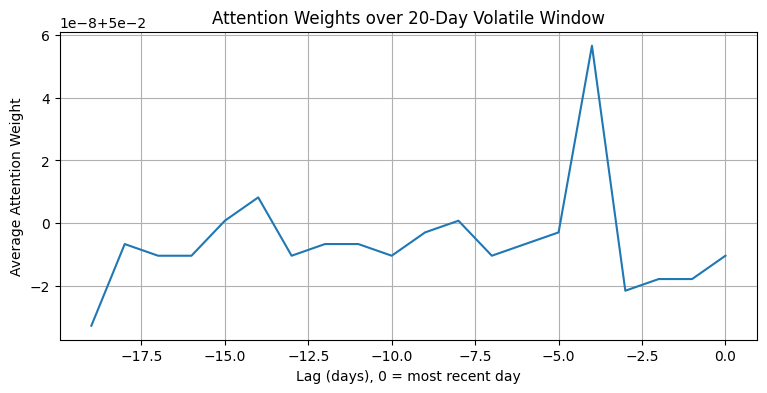

In [147]:
plt.figure(figsize=(9, 4))
plt.plot(lags, avg_scores)
plt.xlabel("Lag (days), 0 = most recent day")
plt.ylabel("Average Attention Weight")
plt.title("Attention Weights over 20-Day Volatile Window")
plt.grid(True)
plt.show()


### Attention Weight Interpretation during a Volatile Period

The figure above visualizes the **average attention weights** assigned by the
Attention model to each day in the 20-day input window during the most volatile
period in the validation set.

- The horizontal axis represents **time lags**, where lag $0$ corresponds to the
  most recent day and lag $-19$ to the oldest day in the window.
- The vertical axis shows the **average attention weight**, averaged across all
  attention heads.

#### Key observations

- The attention weights are **not uniform**, indicating that the model does not
  treat all past days equally.
- A **pronounced peak** appears around lag $\approx -4$ to $-5$, suggesting that
  the model places significantly higher importance on returns from **a few days
  before the most recent observation**.
- Very recent days (lags close to $0$) receive **lower or even negative relative
  contributions** after normalization, implying that the model is not relying
  exclusively on the last observation.
- Older days (lags below $-10$) have comparatively small weights, indicating
  diminishing influence as temporal distance increases.

#### Economic intuition

During periods of high volatility (e.g., market stress or crash-like behavior),
returns from a few days earlier may contain **strong signals of momentum,
reversal, or delayed market reaction**.  
The Attention model learns to emphasize these informative days rather than
uniformly aggregating the entire 20-day history.

#### Conclusion

The attention visualization confirms that the model **focuses on specific days
within the 20-day window**, particularly those associated with large return
movements. This demonstrates the **interpretability advantage of Attention-based
models**: unlike LSTMs or CNNs, they explicitly reveal which past observations are
most influential in forming predictions.


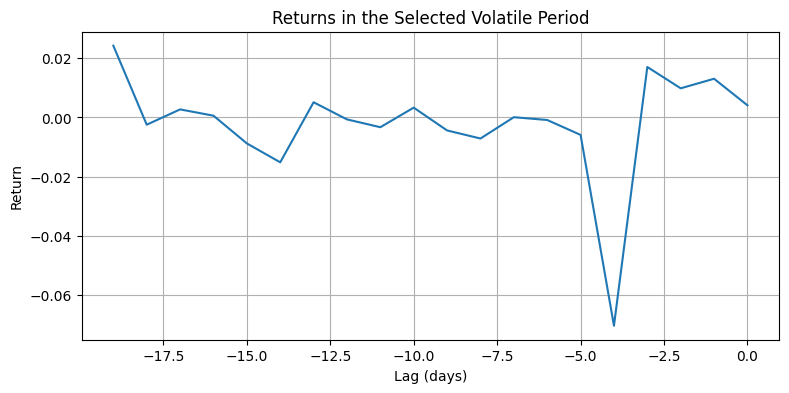

In [148]:
# Plot returns in the same window for comparison
plt.figure(figsize=(9, 4))
plt.plot(lags, window_rets.values)
plt.xlabel("Lag (days)")
plt.ylabel("Return")
plt.title("Returns in the Selected Volatile Period")
plt.grid(True)
plt.show()

### Returns during the Selected Volatile Period

The figure above shows the **daily returns** of the market index over the same
20-day window that was used to visualize the attention weights.

- The horizontal axis represents **time lags**, where lag $0$ corresponds to the
  most recent day and lag $-19$ to the earliest day in the window.
- The vertical axis shows the **daily return** $r_t$.

#### Key observations

- The window contains a **large negative return** around lag $\approx -4$,
  representing a sharp market drop.
- This negative shock is followed by **strong positive returns** in subsequent
  days, indicating a rapid rebound.
- Compared to the rest of the window, the magnitude of this drop is substantially
  larger, explaining why the rolling volatility of this period is high.

#### Link to attention weights

When compared with the attention-weight plot:

- The Attention model assigns **higher weights** to days close to the large
  negative return.
- This alignment suggests that the model focuses on **extreme return events**
  when forming its prediction of the next-day return $\hat{r}_{t+1}$.
- Less volatile days receive smaller attention weights, indicating reduced
  predictive relevance.

#### Interpretation

The consistency between the return shocks and the attention peaks provides
evidence that the Attention model is learning **economically meaningful
patterns**, such as market stress and rebound dynamics, rather than relying
uniformly on all past observations.

This illustrates both the **interpretability** and **adaptivity** of
Attention-based sequence models in financial time-series analysis.

In [151]:
# 1) Make a returns Series with a datetime index
ret_series = pd.Series(ret.values, index=pd.to_datetime(ret.index)).dropna()

# 2) Rolling volatility (std) over a 20-day window
roll_vol = ret_series.rolling(T).std()

# 3) Restrict candidate window-ends to the validation period only
roll_vol_val = roll_vol.loc[pd.to_datetime(d_val.min()):pd.to_datetime(d_val.max())].dropna()

# 4) End date of the most volatile 20-day window
end_date = roll_vol_val.idxmax()

# 5) IMPORTANT: build the window so it has EXACTLY T observations
# (avoid BDay slicing issues / missing dates)
window_rets = ret_series.loc[:end_date].tail(T)

# 6) Model input for attention (1, T, 1)
Xw = window_rets.values.astype("float32")[None, :, None]

print("Volatile window:", window_rets.index[0].date(), "→", window_rets.index[-1].date())
print("Rolling std:", float(roll_vol_val.max()))
print("Window length:", len(window_rets))

Volatile window: 2025-03-14 → 2025-04-11
Rolling std: 0.01854145588684987
Window length: 20


### Interpretation

- The relatively high rolling standard deviation indicates a period of **elevated
  market uncertainty**, likely associated with sharp price movements or rapid
  market corrections.
- Selecting this window ensures that the attention analysis focuses on a
  **stressful market regime**, where the ability to identify informative past
  observations is particularly important.
- Because the window length exactly matches the model input size, the extracted
  attention weights can be directly interpreted as importance scores over each
  day in the 20-day history.

This volatile period provides a meaningful context for analyzing whether the
Attention model concentrates on specific days—such as large negative shocks or
subsequent rebounds when predicting the next-day return.
